- KDE: [custom kde (medium)](https://medium.com/@jtchen2k/kernel-density-estimation-with-python-from-scratch-c200b187b6c4)
- [interactive KDE](https://mathisonian.github.io/kde/)

In [1]:
from pathlib import Path
from scipy import stats
import pandas as pd
import seaborn as sns
import numpy as np
import re
from Bio import SeqIO
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mplc
from matplotlib import colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, to_hex, BoundaryNorm
from matplotlib.patches import Patch

import sys
# sys.path.append("../../scripts")
# from plotting_functions import custom_plots
# plt.rcParams.update(custom_plots())

In [3]:
fasta_path = Path("../../../Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa")
m2or_path = Path("../../../Model/Data_Preparation/processed/m2or_pairs_model.csv")
pred_path = Path("../../predictions/aggregated/Reference_Tree_Predictions/reference_median_prediction_wide.csv")
prob_path = Path("../../predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv")

In [4]:
m2or = pd.read_csv(m2or_path)
m2or

,Species,UniProt ID,Sequence,SMILES,Mixture,Responsive,seq_id,smiles_id,mutation,Class
0,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@H](CC1)C(=C)C,mono,0,SEQ0000,SML0000,False,class 2
1,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CC1=CC[C@@H](CC1=O)C(=C)C,mono,0,SEQ0000,SML0001,False,class 2
2,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,C[C@H]1CC[C@@H]([C@H](C1)O)C(C)C,mono,0,SEQ0000,SML0002,False,class 2
3,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCO,mono,0,SEQ0000,SML0003,False,class 2
4,homo sapiens,Q8NGN2,MTSRSVCEKMTMTTENPNQTVVSHFFLEGLRYTAKHSSLFFLLFLL...,CCCCOCC(C)O,sum of isomers,0,SEQ0000,SML0004,False,class 2
...,...,...,...,...,...,...,...,...,...,...
52170,homo sapiens,A6NGY5,MLQNQDTMEILSNSTSKFPTFLLTGIPGLESAHVWISIPFCCFYAI...,CCCCCC=O,mono,0,SEQ0523,SML0163,False,class 1
52171,homo sapiens,Q8NGJ9,MAIFNNTTSSSSNFLLTAFPGLECAHVWISIPVCCLYTIALLGNSM...,CCCCCC=O,mono,0,SEQ0952,SML0163,False,class 1
52172,homo sapiens,Q8NH55,MLHTNNTQFHPSTFLVVGVPGLEDVHVWIGFPFFAVYLTALLGNII...,CCCCCC=O,mono,0,SEQ0955,SML0163,False,class 1
52173,homo sapiens,Q8NGH7,MTLVSFFSFLSKPLIMLLSNSSWRLSQPSFLLVGIPGLEESQHWIA...,CCCCCC=O,mono,0,SEQ0957,SML0163,False,class 1


In [5]:
probabilities = pd.read_csv(prob_path)
probabilities

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
0,137246.A0A401T3Q8,0.331915,0.050641,0.377894,0.627445,0.839150,0.910303,0.628379,0.764497,0.017423,...,0.624330,0.020470,0.633163,0.813118,0.599852,0.821772,0.015144,0.029032,0.667010,0.011723
1,137246.A0A401T3V3,0.192671,0.023714,0.130067,0.144893,0.135450,0.160684,0.273939,0.039925,0.035243,...,0.452139,0.018458,0.696216,0.893290,0.499263,0.401632,0.013622,0.010109,0.161716,0.009607
2,75743.A0A401NGY3,0.006406,0.006231,0.008732,0.007751,0.213126,0.806655,0.007056,0.007846,0.006194,...,0.417039,0.005563,0.028337,0.013317,0.060697,0.008801,0.005632,0.005811,0.007582,0.005614
3,75743.A0A401PQX7,0.008801,0.007824,0.007384,0.014886,0.119535,0.741248,0.008512,0.015413,0.009936,...,0.301025,0.013015,0.877761,0.589754,0.076902,0.011488,0.007928,0.005854,0.018178,0.007308
4,7740.A0A8J9ZM08,0.675486,0.850768,0.175001,0.547529,0.748996,0.952015,0.266431,0.581720,0.090510,...,0.354741,0.147090,0.900361,0.896491,0.276700,0.920385,0.595797,0.038390,0.301962,0.032733
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,9606.Q9Y3N9,0.972117,0.979209,0.902062,0.875293,0.978481,0.979184,0.831832,0.983400,0.568778,...,0.722564,0.865544,0.969271,0.976254,0.530206,0.977617,0.980690,0.578110,0.968841,0.648616
580,9606.Q9Y4A9,0.005906,0.005473,0.007260,0.006178,0.010990,0.007117,0.006050,0.006746,0.007215,...,0.015835,0.007087,0.034642,0.035349,0.013781,0.012528,0.005134,0.006376,0.006280,0.005390
581,9606.Q9Y585,0.593257,0.208642,0.435254,0.392526,0.911158,0.960671,0.309913,0.867918,0.011755,...,0.329302,0.020842,0.132792,0.349411,0.272278,0.879067,0.009207,0.024040,0.529328,0.019009
582,9606.Q9Y5P0,0.517906,0.065085,0.515711,0.331530,0.638879,0.392088,0.413768,0.237446,0.012486,...,0.831786,0.013537,0.686598,0.263093,0.874698,0.262162,0.008114,0.009798,0.421188,0.010830


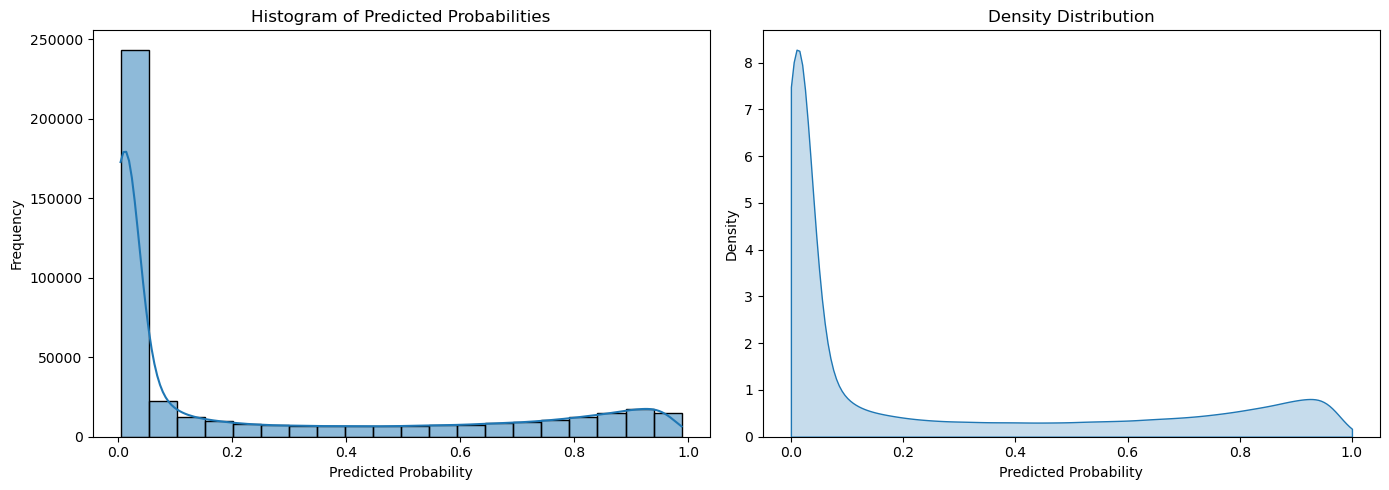

In [6]:
probabilities_melted = probabilities.melt(
    id_vars='protein_id',
    var_name='smiles',
    value_name='probability'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=probabilities_melted,
    x='probability',
    bins=20,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Histogram of Predicted Probabilities')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Frequency')

sns.kdeplot(
    data=probabilities_melted,
    x='probability',
    fill=True,
    bw_adjust=1,
    clip=(0, 1),
    ax=axes[1]
)
axes[1].set_title('Density Distribution')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [7]:
predictions = pd.read_csv(pred_path)
predictions

,protein_id,SML0000,SML0001,SML0002,SML0003,SML0004,SML0005,SML0006,SML0007,SML0008,...,SML0744,SML0745,SML0746,SML0747,SML0748,SML0749,SML0750,SML0768,SML0769,SML0770
0,137246.A0A401T3Q8,0,0,0,1,1,1,1,1,0,...,1,0,1,1,1,1,0,0,1,0
1,137246.A0A401T3V3,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,75743.A0A401NGY3,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,75743.A0A401PQX7,0,0,0,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,0
4,7740.A0A8J9ZM08,1,1,0,1,1,1,0,1,0,...,0,0,1,1,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,9606.Q9Y3N9,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
580,9606.Q9Y4A9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581,9606.Q9Y585,1,0,0,0,1,1,0,1,0,...,0,0,0,0,0,1,0,0,1,0
582,9606.Q9Y5P0,1,0,1,0,1,0,0,0,0,...,1,0,1,0,1,0,0,0,0,0


## Common pairs: experimental ∩ predicted

Join key is **amino acid sequence**.
Final table keeps only `(protein, smiles)` pairs where a ground-truth experimental label exists.

In [8]:
# Predicted side
fasta_seqs = {rec.id: str(rec.seq) for rec in SeqIO.parse(fasta_path, "fasta")}

sml_cols = [c for c in predictions.columns if c.startswith("SML")]

human_pred_wide = predictions[predictions["protein_id"].str.startswith("9606")].copy()
human_prob_wide  = probabilities[probabilities["protein_id"].str.startswith("9606")].copy()

human_pred_wide["sequence"]   = human_pred_wide["protein_id"].map(fasta_seqs)
human_prob_wide["sequence"]   = human_prob_wide["protein_id"].map(fasta_seqs)
human_pred_wide["uniprot_id"] = human_pred_wide["protein_id"].str.split(".").str[1]

n_found = human_pred_wide["sequence"].notna().sum()
print(f"Human proteins in predictions : {len(human_pred_wide)}")
print(f"Sequences resolved from fasta : {n_found}  (missing: {len(human_pred_wide) - n_found})")

Human proteins in predictions : 433
Sequences resolved from fasta : 433  (missing: 0)


In [9]:
# Experimental side
human_exp = (
    m2or[m2or["Species"] == "homo sapiens"]
    [["UniProt ID", "Sequence", "seq_id", "smiles_id", "SMILES", "Responsive", "mutation", "Class"]]
    .copy()
    .rename(columns={"UniProt ID": "uniprot_id", "Sequence": "sequence"})
)

# Wide matrix: rows = unique sequences, columns = smiles_id, values = Responsive
# aggfunc='max': if the same (sequence, smiles) was tested more than once, any positive = 1
exp_wide = human_exp.pivot_table(
    index="sequence",
    columns="smiles_id",
    values="Responsive",
    aggfunc="max"
)

print(f"Unique human sequences in m2or : {len(exp_wide)}")
print(f"Unique SMILES tested           : {exp_wide.shape[1]}")

Unique human sequences in m2or : 1202
Unique SMILES tested           : 663


In [10]:
# Common pairs: Intersect SMILES and sequences present in both sources
common_sml  = sorted(set(sml_cols) & set(exp_wide.columns))
common_seqs = sorted(
    set(human_pred_wide["sequence"].dropna()) & set(exp_wide.index)
)

print(f"SMILES in predictions  : {len(sml_cols)}")
print(f"SMILES in experimental : {exp_wide.shape[1]}")
print(f"SMILES in common       : {len(common_sml)}")
print()
print(f"Proteins in predictions  : {len(human_pred_wide)}")
print(f"Proteins in experimental : {len(exp_wide)}")
print(f"Proteins in common       : {len(common_seqs)}")

# Align both matrices to the common (sequence × smiles) grid
pred_idx = human_pred_wide.dropna(subset=["sequence"]).drop_duplicates("sequence").set_index("sequence")
prob_idx = human_prob_wide.dropna(subset=["sequence"]).drop_duplicates("sequence").set_index("sequence")

exp_aligned  = exp_wide.loc[common_seqs, common_sml]
pred_aligned = pred_idx.loc[common_seqs, common_sml]
prob_aligned = prob_idx.loc[common_seqs, common_sml]

# Melt all three to long format and merge on (sequence, smiles_id)
exp_long  = exp_aligned.reset_index().melt(id_vars="sequence", var_name="smiles_id", value_name="experimental")
pred_long = pred_aligned.reset_index().melt(id_vars="sequence", var_name="smiles_id", value_name="predicted")
prob_long = prob_aligned.reset_index().melt(id_vars="sequence", var_name="smiles_id", value_name="probability")

common_pairs = (
    exp_long
    .merge(pred_long, on=["sequence", "smiles_id"])
    .merge(prob_long,  on=["sequence", "smiles_id"])
)

# Keep only pairs with a ground-truth label (drop untested = NaN experimental)
common_pairs = common_pairs.dropna(subset=["experimental"]).copy()
common_pairs["experimental"] = common_pairs["experimental"].astype(int)

# Attach metadata: SMILES string, seq_id, uniprot_id, mutation status, OR class
smiles_str    = m2or[["smiles_id", "SMILES"]].drop_duplicates("smiles_id").set_index("smiles_id")["SMILES"]
seq_meta_exp  = human_exp.drop_duplicates("sequence").set_index("sequence")[["seq_id", "mutation", "Class"]]
seq_meta_pred = human_pred_wide.drop_duplicates("sequence").set_index("sequence")[["uniprot_id"]]

common_pairs["SMILES"]     = common_pairs["smiles_id"].map(smiles_str)
common_pairs["seq_id"]     = common_pairs["sequence"].map(seq_meta_exp["seq_id"])
common_pairs["uniprot_id"] = common_pairs["sequence"].map(seq_meta_pred["uniprot_id"])
common_pairs["mutation"]   = common_pairs["sequence"].map(seq_meta_exp["mutation"])
common_pairs["OR_class"]   = common_pairs["sequence"].map(seq_meta_exp["Class"])

# Canonical column order
common_pairs = common_pairs[[
    "uniprot_id", "seq_id", "sequence", "smiles_id", "SMILES",
    "experimental", "predicted", "probability",
    "mutation", "OR_class"
]].reset_index(drop=True)

print(f"\ncommon_pairs shape : {common_pairs.shape}")
print(f"  Responsive   (exp=1) : {(common_pairs['experimental']==1).sum()}")
print(f"  Non-responsive (exp=0) : {(common_pairs['experimental']==0).sum()}")
print(f"  Unique proteins  : {common_pairs['sequence'].nunique()}")
print(f"  Unique SMILES    : {common_pairs['smiles_id'].nunique()}")
print(f"  Wild-type pairs  : {(~common_pairs['mutation']).sum()}")
print(f"  Mutant pairs     : {common_pairs['mutation'].sum()}")
common_pairs

SMILES in predictions  : 754
SMILES in experimental : 663
SMILES in common       : 663

Proteins in predictions  : 433
Proteins in experimental : 1202
Proteins in common       : 409

common_pairs shape : (23782, 10)
  Responsive   (exp=1) : 1128
  Non-responsive (exp=0) : 22654
  Unique proteins  : 409
  Unique SMILES    : 652
  Wild-type pairs  : 23594
  Mutant pairs     : 188


,uniprot_id,seq_id,sequence,smiles_id,SMILES,experimental,predicted,probability,mutation,OR_class
0,Q8NG83,SEQ0039,MARENSTFNSDFILLGIFNHSPTHTFLFFLVLAIFSVAFMGNSVMV...,SML0000,CC1=CC[C@H](CC1)C(=C)C,0,0,0.011647,False,class 2
1,Q7Z3T1,SEQ0007,MDGTNGSTQTHFILLGFSDRPHLERILFVVILIAYLLTLVGNTTII...,SML0000,CC1=CC[C@H](CC1)C(=C)C,0,0,0.006946,False,class 2
2,Q8NH00,SEQ0006,MDNITWMASHTGWSDFILMGLFRQSKHPMANITWMANHTGWSDFIL...,SML0000,CC1=CC[C@H](CC1)C(=C)C,0,0,0.047739,False,class 2
3,Q9Y3N9,SEQ0050,MDQSNYSSLHGFILLGFSNHPKMEMILSGVVAIFYLITLVGNTAII...,SML0000,CC1=CC[C@H](CC1)C(=C)C,0,1,0.972117,False,class 2
4,Q8N349,SEQ0005,MEKWNHTSNDFILLGLLPPNQTGIFLLCLIILIFFLASVGNSAMIH...,SML0000,CC1=CC[C@H](CC1)C(=C)C,0,0,0.006383,False,class 2
...,...,...,...,...,...,...,...,...,...,...
23777,O43869,SEQ0530,MWQEYYFLNVFFPLLKVCCLTINSHVVILLPWECYHLIWKILPYIG...,SML0770,CC1=CC2=C(C=C1)C(CC=C2)(C)C,0,0,0.005213,False,class 2
23778,Q8NHA4,SEQ0639,MWQKNQTSLADFILEGLFDDSLTHLFLFSLTMVVFLIAVSGNTLTI...,SML0770,CC1=CC2=C(C=C1)C(CC=C2)(C)C,0,0,0.007664,False,class 2
23779,Q9Y5P0,SEQ0894,MWYNNSAGPFLLTGFLGSEAVHYRISMSFFVIYFSVLFGNGTLLVL...,SML0770,CC1=CC2=C(C=C1)C(CC=C2)(C)C,0,0,0.010830,False,class 1
23780,Q8NGV5,SEQ0877,MYRFTDFDVSNISIYLNHVLFYTTQQAGDLEHMETRNYSAMTEFFL...,SML0770,CC1=CC2=C(C=C1)C(CC=C2)(C)C,0,0,0.004966,False,class 2


In [11]:
# MAP SEQ_ID TO m2or_pairs.csv (Data/m2or_pairs.csv) for more info for the supplementary table 


# ============================================================
# AUDIT: m2or vs UniProt SwissProt sequence discordance
# ------------------------------------------------------------
# m2or flags some sequences as `mutation=True` whose strings are
# byte-identical to the SwissProt canonical sequence in our FASTA
# reference. For these UniProt IDs, m2or's "WT" form differs from
# SwissProt by one or more residues. We trust SwissProt (curated,
# matches our prediction set) and therefore do NOT filter on the
# m2or `mutation` flag. This block identifies and exports the
# discordant cases for the supplementary table; it does not alter
# the analysis dataframes.
# ============================================================

fasta_wt_seqs = set(fasta_seqs.values())

# m2or rows flagged mutant whose sequence equals a SwissProt WT
mutant_rows = m2or[(m2or["Species"] == "homo sapiens") & (m2or["mutation"])]
discordant = (mutant_rows[mutant_rows["Sequence"].isin(fasta_wt_seqs)]
              [["UniProt ID", "seq_id", "Sequence"]]
              .drop_duplicates("Sequence")
              .rename(columns={"UniProt ID": "uniprot_id",
                               "Sequence":   "m2or_mutant_sequence_matches_swissprot"}))

# Pair each with m2or's "WT" sequence for the same UniProt (if any)
m2or_wt = (m2or[(m2or["Species"] == "homo sapiens") & (~m2or["mutation"])]
           [["UniProt ID", "Sequence"]]
           .drop_duplicates("UniProt ID")
           .rename(columns={"UniProt ID": "uniprot_id",
                            "Sequence":   "m2or_wt_sequence"}))
discordant = discordant.merge(m2or_wt, on="uniprot_id", how="left")

print(f"[AUDIT] m2or-vs-SwissProt discordant receptors: {len(discordant)}")
print(f"        Decision: trust SwissProt; m2or `mutation` flag NOT applied.")
print(f"        These rows remain in the analysis as wild-type.")
print(discordant[["uniprot_id", "seq_id"]].to_string(index=False))

# Export for supplementary table
#discordant.to_csv("supplementary_m2or_swissprot_discordance.csv", index=False)

[AUDIT] m2or-vs-SwissProt discordant receptors: 5
        Decision: trust SwissProt; m2or `mutation` flag NOT applied.
        These rows remain in the analysis as wild-type.
uniprot_id  seq_id
    Q8TCB6 SEQ0099
    Q8NGR9 SEQ0420
    Q8NGJ2 SEQ0493
    Q8NGC5 SEQ0781
    Q8NGH7 SEQ0926


## Predicted probability distribution
What probabilities did the model give to experimentally tested pairs

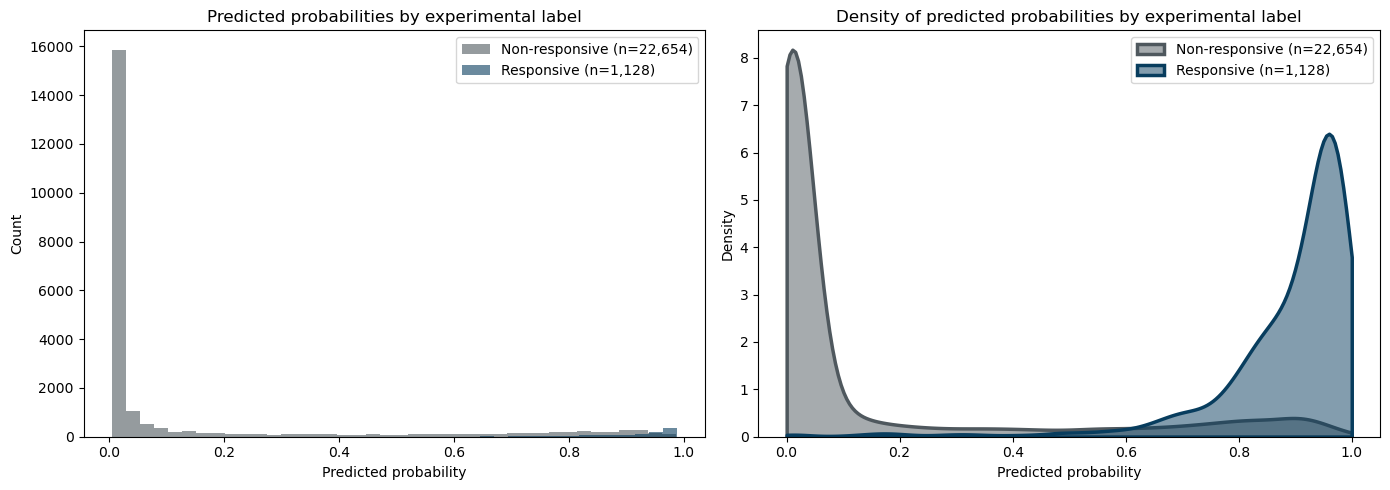

In [12]:
n0 = (common_pairs["experimental"] == 0).sum()
n1 = (common_pairs["experimental"] == 1).sum()
palette     = {0: "#4f585e", 1: "#083d5e"}
label_names = {0: f"Non-responsive (n={n0:,})", 1: f"Responsive (n={n1:,})"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, grp in common_pairs.groupby("experimental"):
    axes[0].hist(
        grp["probability"], bins=40,
        alpha=0.6, color=palette[label],
        label=label_names[label], edgecolor="none"
    )
axes[0].set_title("Predicted probabilities by experimental label")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Count")
axes[0].legend()

# Density
for label, grp in common_pairs.groupby("experimental"):
    sns.kdeplot(
        grp["probability"],
        fill=True, alpha=0.5, 
        linewidth=2.5,
        color=palette[label],
        label=label_names[label],
        bw_adjust=1, clip=(0, 1), ax=axes[1]
    )
axes[1].set_title("Density of predicted probabilities by experimental label")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

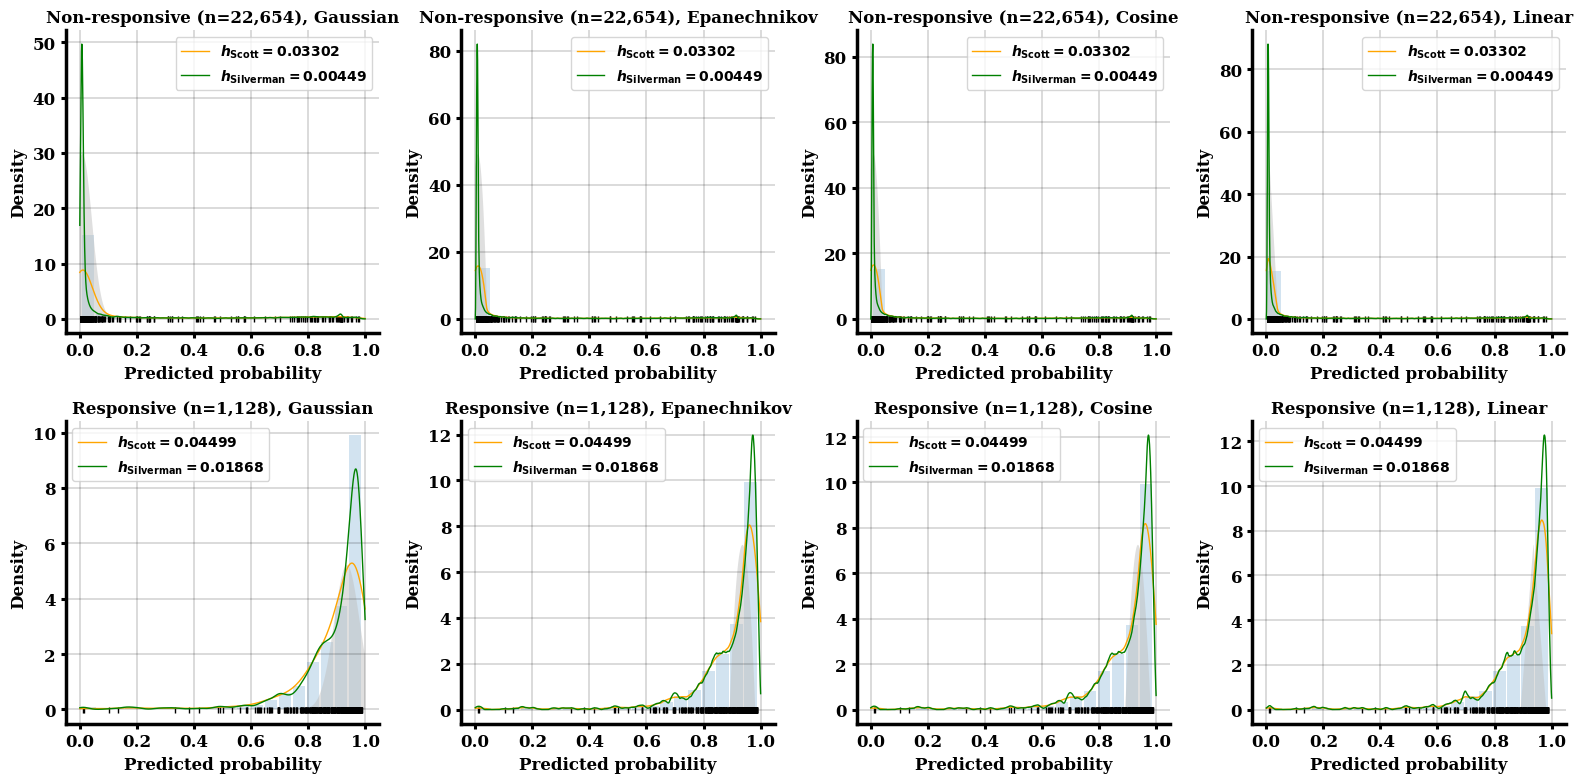

In [13]:
def bw_scott(data: np.ndarray):
    std_dev = np.std(data, axis=0, ddof=1)
    n = len(data)
    return 3.49 * std_dev * n ** (-0.333)

def bw_silverman(data: np.ndarray):
    def _select_sigma(x):
        normalizer = 1.349
        iqr = (stats.scoreatpercentile(x, 75) - stats.scoreatpercentile(x, 25)) / normalizer
        std_dev = np.std(x, axis=0, ddof=1)
        return np.minimum(std_dev, iqr) if iqr > 0 else std_dev
    sigma = _select_sigma(data)
    n = len(data)
    return 0.9 * sigma * n ** (-0.2)

def bw_mlcv(data: np.ndarray, k):
    """
    Ref: https://rdrr.io/cran/kedd/src/R/MLCV.R
    """
    n = len(data)
    x = np.linspace(np.min(data), np.max(data), n)
    def mlcv(h):
        fj = np.zeros(n)
        for j in range(n):
            for i in range(n):
                if i == j: continue
                fj[j] += k((x[j] - data[i]) / h)
            fj[j] /= (n - 1) * h
        return -np.mean(np.log(fj[fj > 0]))
    h = optimize.minimize(mlcv, 1)
    if np.abs(h.x[0]) > 10:
        return bw_scott(data)
    return h.x[0]

# ── KDE parameter exploration on actual probability data ────────────────────
# Mirrors run_kde exactly:
#   • silver fill  = kernel shape K centred at median (replaces "true dist")
#   • grey hist    = ax.hist(density=True, alpha=0.2)
#   • rug          = ax.plot '|k'  (subsampled for readability at n≈22k)
#   • 3 lines      = orange=Scott, green=Silverman, red=MLCV
#
# Grid: rows = experimental group, columns = kernel
#
# MLCV: vectorised + subsampled (max 500 pts) so it runs in <2 s per call.

def kde_fast(data: np.ndarray, kern_name: str, h: float, x: np.ndarray) -> np.ndarray:
    """Vectorised kde() — same math as cell 18, numpy broadcasting."""
    u = (x[:, None] - data[None, :]) / h
    if   kern_name == 'gaussian':
        K = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
    elif kern_name == 'epanechnikov':
        K = np.where(np.abs(u) <= 1, 0.75 * (1 - u**2),                  0.0)
    elif kern_name == 'cosine':
        K = np.where(np.abs(u) <= 1, np.pi / 4 * np.cos(np.pi / 2 * u),  0.0)
    elif kern_name == 'linear':
        K = np.where(np.abs(u) <= 1, 1 - np.abs(u),                       0.0)
    return np.maximum(K.mean(axis=1) / h, 0)


def eval_kernel(kern_name: str, u: np.ndarray) -> np.ndarray:
    """K(u) element-wise."""
    if   kern_name == 'gaussian':
        return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
    elif kern_name == 'epanechnikov':
        return np.where(np.abs(u) <= 1, 0.75 * (1 - u**2),                  0.0)
    elif kern_name == 'cosine':
        return np.where(np.abs(u) <= 1, np.pi / 4 * np.cos(np.pi / 2 * u),  0.0)
    elif kern_name == 'linear':
        return np.where(np.abs(u) <= 1, 1 - np.abs(u),                       0.0)
    return np.zeros_like(u, dtype=float)


def bw_mlcv_fast(data: np.ndarray, kern_name: str, max_n: int = 500) -> float:
    """Vectorised MLCV with subsampling — mirrors bw_mlcv but O(max_n²) not O(n²)."""
    np.random.seed(42)
    sub = data if len(data) <= max_n else np.random.choice(data, max_n, replace=False)
    n   = len(sub)
    xg  = np.linspace(sub.min(), sub.max(), n)

    def mlcv(h):
        h  = abs(h) + 1e-8
        K  = eval_kernel(kern_name, (xg[:, None] - sub[None, :]) / h)
        np.fill_diagonal(K, 0.0)
        fj = K.sum(axis=1) / ((n - 1) * h)
        m  = fj > 0
        return -np.mean(np.log(fj[m])) if m.any() else 1e10

    res = optimize.minimize_scalar(mlcv, bounds=(0.001, 2.0), method='bounded')
    return abs(float(res.x))


# ── data ──────────────────────────────────────────────────────────────────────
x_plot  = np.linspace(0, 1, 1000)
RUG_MAX = 500

group_data = [
    (f"Non-responsive (n={n0:,})",
     common_pairs.loc[common_pairs["experimental"] == 0, "probability"].to_numpy()),
    (f"Responsive (n={n1:,})",
     common_pairs.loc[common_pairs["experimental"] == 1, "probability"].to_numpy()),
]

kern_names  = ['gaussian', 'epanechnikov', 'cosine', 'linear']
kern_labels = ['Gaussian', 'Epanechnikov', 'Cosine', 'Linear']

# (label, callable(data, kern_name)->h, line colour) — mirrors bw_algorithms
bw_cfg = [
    ('Scott',     lambda x, k: bw_scott(x),        'orange'),
    ('Silverman', lambda x, k: bw_silverman(x),     'green'),
    #('MLCV',      bw_mlcv_fast,                     'red'),
]

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axs = plt.subplots(len(group_data), len(kern_names), figsize=(16, 8))

for row, (group_title, x_data) in enumerate(group_data):
    for col, (kern_name, kern_label) in enumerate(zip(kern_names, kern_labels)):
        ax = axs[row, col]
        ax.grid(True)

        # 1. Histogram
        ax.hist(x_data, density=True, alpha=0.2, bins=20, rwidth=0.9)

        # 2. Rug plot (subsampled so marks stay readable)
        np.random.seed(0)
        rug = (x_data if len(x_data) <= RUG_MAX
               else np.random.choice(x_data, RUG_MAX, replace=False))
        ax.plot(rug, np.full_like(rug, -0.02), '|k', markeredgewidth=1)

        # 3. KDE curves — compute first to determine max_y for silver scaling
        curves = []
        for bw_name, bw_fn, color in bw_cfg:
            h = bw_fn(x_data, kern_name)
            y = kde_fast(x_data, kern_name, h, x_plot)
            curves.append((bw_name, h, y, color))

        max_y = max(y.max() for _, _, y, _ in curves)

        # 4. Kernel shape in silver (centred at median, normalised to 60 % of max_y)
        h_ref   = bw_scott(x_data)
        K_shape = eval_kernel(kern_name, (x_plot - np.median(x_data)) / h_ref) / h_ref
        K_shape = np.maximum(K_shape / (K_shape.max() + 1e-10) * max_y * 0.6, 0)
        ax.fill_between(x_plot, K_shape, fc='silver', alpha=0.5)

        # 5. KDE lines (one per bandwidth algorithm)
        for bw_name, h, y, color in curves:
            ax.plot(x_plot, y, linewidth=1, color=color,
                    label=f'$h_{{\\mathrm{{{bw_name}}}}} = {round(h, 5)}$')

        ax.legend(loc='best', fontsize='small')
        ax.set_title(f'{group_title}, {kern_label}')
        #ax.set_xlim(0, 1)
        ax.set_xlabel('Predicted probability')
        ax.set_ylabel('Density')

fig.tight_layout()
plt.show()

## Binding proportion: experimental vs predicted

- **Left**: one point per human OR receptor → captures whether the model preserves receptor "tuning breadth"  
- **Right**: one point per odorant → captures whether the model preserves odor "receptor coverage"  

Dashed line = perfect agreement (y = x). Red line = OLS regression.

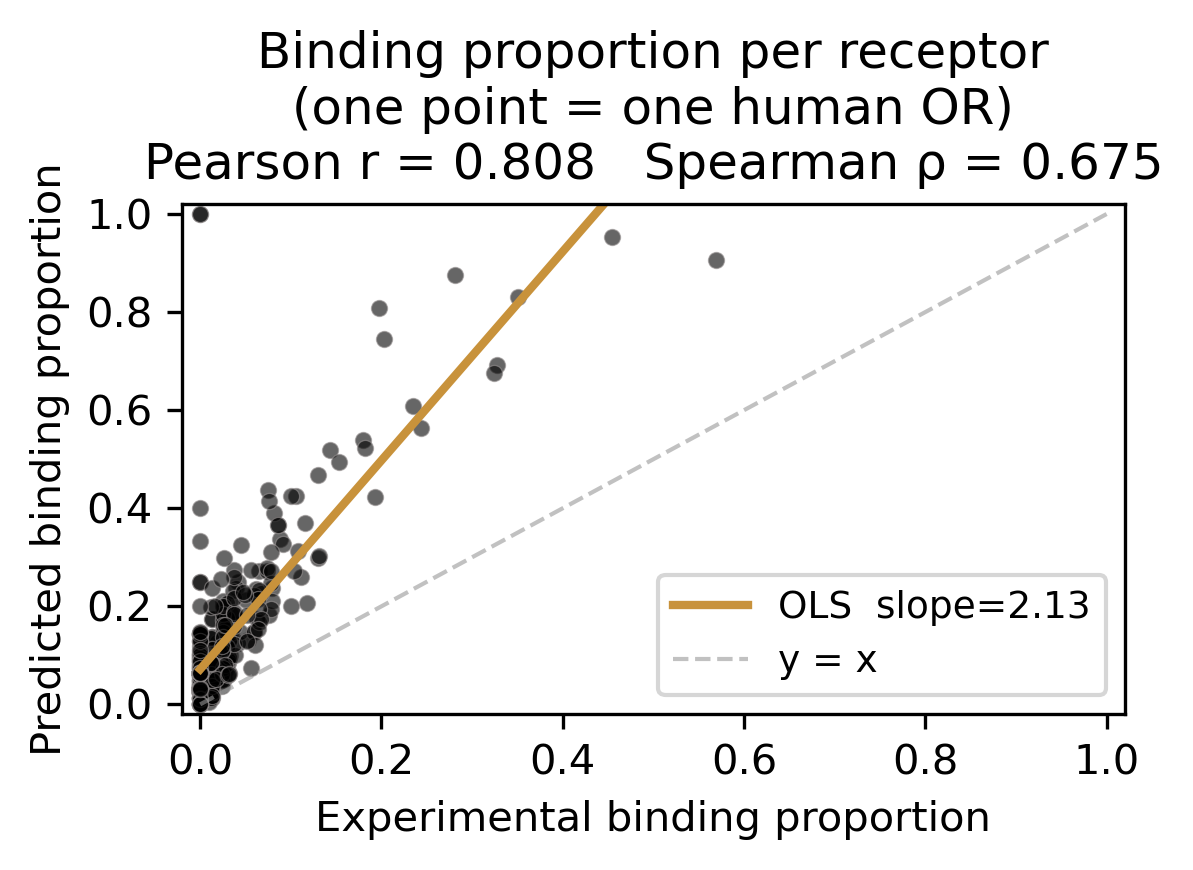

In [15]:
# ---- colours (change these two) ----
DOT_COLOR  = "#000000"   # scatter points
LINE_COLOR = "#C8923B"   # OLS regression line
REF_COLOR  = "#999999"   # y = x reference (unchanged role)

# Per-receptor: denominator = smiles tested for that receptor in common_pairs
receptor_props = (
    common_pairs
    .groupby("sequence")
    .agg(
        exp_prop  = ("experimental", "mean"),
        pred_prop = ("predicted",    "mean"),
        n_pairs   = ("experimental", "count")
    )
    .reset_index()
)

# Per-ligand: denominator = proteins tested against that smiles in common_pairs
ligand_props = (
    common_pairs
    .groupby("smiles_id")
    .agg(
        exp_prop  = ("experimental", "mean"),
        pred_prop = ("predicted",    "mean"),
        n_pairs   = ("experimental", "count")
    )
    .reset_index()
)

datasets = [
    (receptor_props, "Binding proportion per receptor\n(one point = one human OR)"),
    #(ligand_props,   "Binding proportion per ligand\n(one point = one odorant)"),
]

for df, title in datasets:
    fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

    r_p, _ = stats.pearsonr(df["exp_prop"],  df["pred_prop"])
    r_s, _ = stats.spearmanr(df["exp_prop"], df["pred_prop"])

    ax.scatter(df["exp_prop"], df["pred_prop"], color=DOT_COLOR, alpha=0.6, s=15, edgecolors="#999494", linewidths=0.3)

    # OLS regression line
    m, b   = np.polyfit(df["exp_prop"], df["pred_prop"], 1)
    x_fit  = np.linspace(0, 1, 200)
    ax.plot(x_fit, m * x_fit + b, color=LINE_COLOR, lw=2, label=f"OLS  slope={m:.2f}")

    # Perfect-agreement reference
    ax.plot([0, 1], [0, 1], color=REF_COLOR, lw=1, ls="--", alpha=0.6, label="y = x")

    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel("Experimental binding proportion")
    ax.set_ylabel("Predicted binding proportion")
    ax.set_title(f"{title}\nPearson r = {r_p:.3f}   Spearman ρ = {r_s:.3f}")
    ax.legend(fontsize=9)
    #plt.savefig("Figures/proportions_scatter.svg", dpi=300)
    plt.tight_layout()
    plt.show()

## Ligands per receptor

For each human OR, how many odorants does it respond to?  
**Experimental**: counted from tested pairs only (limited to what was measured).  
**Predicted**: counted from the full `pred_aligned` matrix (all 663 common SMILES per receptor) — not restricted to tested pairs.

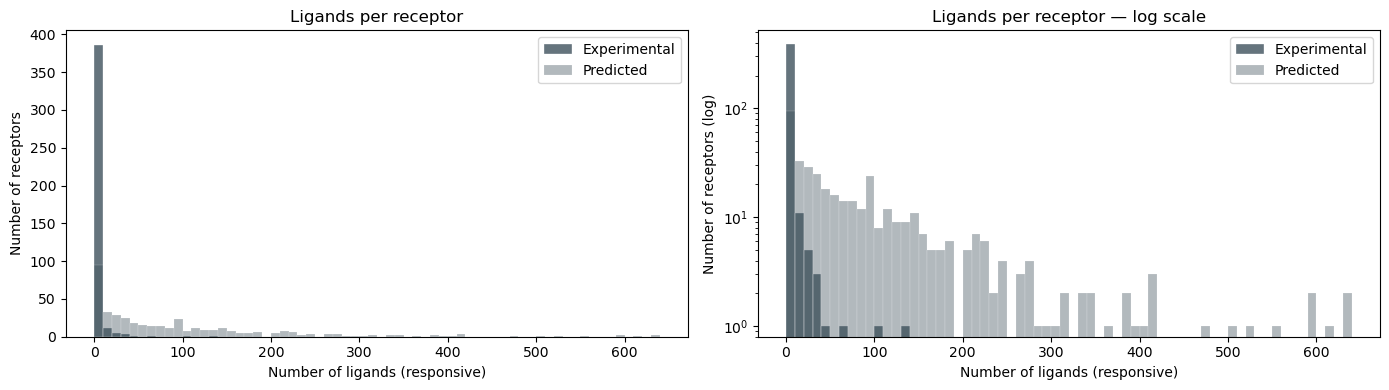

In [13]:
# Experimental: only tested (sequence, smiles) pairs where exp=1
n_lig_exp = (common_pairs[common_pairs["experimental"]==1]
             .groupby("sequence")["smiles_id"].count()
             .reindex(pd.Index(common_seqs), fill_value=0))

# Predicted: sum over ALL 663 common SMILES for each receptor (full pred_aligned grid)
# Using common_pairs here would wrongly restrict to the tested smiles per receptor
n_lig_pred = pred_aligned.sum(axis=1)

max_val = int(max(n_lig_exp.max(), n_lig_pred.max()))
step    = max(1, max_val // 60)
bins    = np.arange(0, max_val + step + 1, step)
color   = "#3f515c"

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, log in zip(axes, [False, True]):
    ax.hist(n_lig_exp.values,  bins=bins, alpha=0.8, color=color,
            label="Experimental", edgecolor="white", linewidth=0.3)
    ax.hist(n_lig_pred.values, bins=bins, alpha=0.4, color=color,
            label="Predicted",    edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Number of ligands (responsive)")
    ax.legend()
    if log:
        ax.set_yscale("log")
        ax.set_ylim(bottom=0.8)
        ax.set_ylabel("Number of receptors (log)")
        ax.set_title("Ligands per receptor — log scale")
    else:
        ax.set_ylabel("Number of receptors")
        ax.set_title("Ligands per receptor")

plt.tight_layout()
plt.show()

## Receptors per ligand

For each odorant, how many human ORs does it activate?  
**Experimental**: counted from tested pairs only.  
**Predicted**: counted from the full `pred_aligned` matrix (all 409 common receptors per SMILES) — not restricted to tested pairs. Reindexed to all 663 common SMILES.

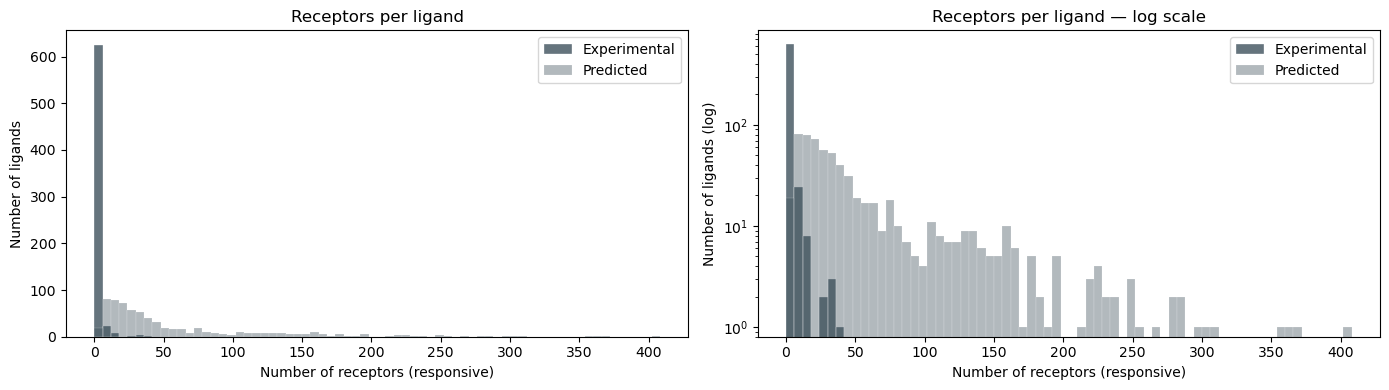

In [14]:
# Experimental: only tested (sequence, smiles) pairs where exp=1
# Reindex to ALL 663 common SMILES so the denominator matches pred_aligned
n_rec_exp  = (common_pairs[common_pairs["experimental"]==1]
              .groupby("smiles_id")["sequence"].count()
              .reindex(pd.Index(common_sml), fill_value=0))

# Predicted: sum over ALL 409 common receptors for each SMILES (full pred_aligned grid)
# Using common_pairs here would wrongly restrict to the tested receptors per smiles
n_rec_pred = pred_aligned.sum(axis=0)

max_val = int(max(n_rec_exp.max(), n_rec_pred.max()))
step    = max(1, max_val // 60)
bins    = np.arange(0, max_val + step + 1, step)
color   = "#3f515c"

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, log in zip(axes, [False, True]):
    ax.hist(n_rec_exp.values,  bins=bins, alpha=0.8, color=color,
            label="Experimental", edgecolor="white", linewidth=0.3)
    ax.hist(n_rec_pred.values, bins=bins, alpha=0.4, color=color,
            label="Predicted",    edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Number of receptors (responsive)")
    ax.legend()
    if log:
        ax.set_yscale("log")
        ax.set_ylim(bottom=0.8)
        ax.set_ylabel("Number of ligands (log)")
        ax.set_title("Receptors per ligand — log scale")
    else:
        ax.set_ylabel("Number of ligands")
        ax.set_title("Receptors per ligand")

plt.tight_layout()
plt.show()

In [53]:
#common_pairs.to_csv("metadata/exp_pred_common_pairs.csv", index=False)

## Confusion matrix

Binary classification of `common_pairs` at the model's default 0.5 threshold.  
Each quadrant has its own colour; cells show the category label, absolute count, and percentage of all pairs.

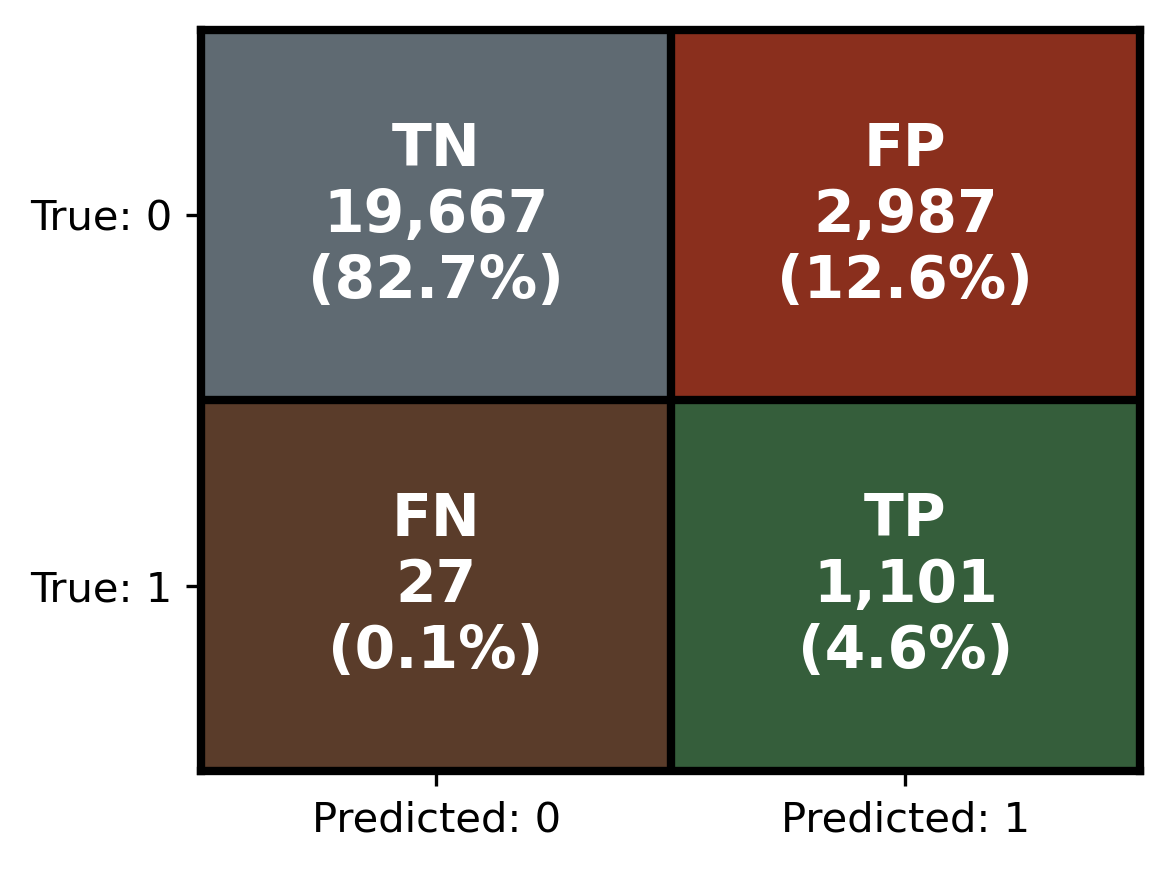

In [17]:
from sklearn.metrics import confusion_matrix
from matplotlib.colors import to_rgb

cm_colors = {"TP": "#355E3B", "FP": "#8A2F1D", "FN": "#5A3C2A", "TN": "#5F6A72"}

y_true = common_pairs["experimental"].values
y_pred = common_pairs["predicted"].values

# sklearn layout: [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
total = tn + fp + fn + tp

values = np.array([[tn, fp], [fn, tp]])
labels = np.array([["TN", "FP"], ["FN", "TP"]])

color_grid = np.array([
    [to_rgb(cm_colors["TN"]), to_rgb(cm_colors["FP"])],
    [to_rgb(cm_colors["FN"]), to_rgb(cm_colors["TP"])],
])

fig, ax = plt.subplots(figsize=(4, 3), dpi=300)
ax.imshow(color_grid, aspect="auto")

# Cell separating lines (imshow pixel centres at 0 and 1, boundary at 0.5)
ax.axvline(0.5, color="black", lw=2, zorder=5)
ax.axhline(0.5, color="black", lw=2, zorder=5)
for spine in ax.spines.values():
    spine.set_linewidth(2)

for i in range(2):
    for j in range(2):
        count = values[i, j]
        pct   = count / total * 100
        ax.text(j, i, f"{labels[i,j]}\n{count:,}\n({pct:.1f}%)",
                ha="center", va="center",
                fontsize=14, fontweight="bold", color="white")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Predicted: 0", "Predicted: 1"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["True: 0", "True: 1"])
plt.savefig("Figures/confusion_matrix_common_pairs.svg", dpi=300, bbox_inches="tight")
#ax.set_title(f"Confusion matrix — common pairs (n={total:,})")
plt.tight_layout()
plt.show()

# Assign cm_category for reuse in the probability density plot
# np.where on numpy arrays avoids the pandas Series ambiguity error of np.select
exp  = common_pairs["experimental"].to_numpy()
pred = common_pairs["predicted"].to_numpy()
common_pairs["cm_category"] = np.where(
    exp == 1,
    np.where(pred == 1, "TP", "FN"),
    np.where(pred == 1, "FP", "TN")
)

## Classification metrics

Threshold-dependent metrics use the binary `predicted` column (0.5 threshold).  
Threshold-independent metrics (ROC AUC, PR AUC, RMSE, Kendall τ) use the raw `probability` column.

| Group | Metrics |
|---|---|
| Ranking / calibration | ROC AUC, PR AUC, RMSE, Kendall τ |
| Binary classification | Accuracy, Balanced Accuracy, MCC |
| Per-class | Sensitivity = TP/(TP+FN), Specificity = TN/(TN+FP) |

In [18]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              balanced_accuracy_score, accuracy_score,
                              matthews_corrcoef, mean_squared_error,
                              f1_score, precision_score, recall_score)

y_true = common_pairs["experimental"]
y_pred = common_pairs["predicted"]
y_prob = common_pairs["probability"]

sensitivity = tp / (tp + fn)   # == recall_score
specificity = tn / (tn + fp)

metrics_df = pd.DataFrame({
    "Metric": [
        "ROC AUC",
        "PR AUC",
        "Pearson r (probability vs label)",
        "Kendall τ (probability vs label)",
        "Balanced Accuracy",
        "Accuracy",
        "MCC",
        "F1",
        "Precision (PPV)",
        "Recall = Sensitivity (TP rate)",
        "Specificity (TN rate)",
        "RMSE (probability vs label)",
    ],
    "Value": [
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        stats.pearsonr(y_true, y_prob).statistic,
        stats.kendalltau(y_true, y_prob).statistic,
        balanced_accuracy_score(y_true, y_pred),
        accuracy_score(y_true, y_pred),
        matthews_corrcoef(y_true, y_pred),
        f1_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        specificity,
        np.sqrt(mean_squared_error(y_true, y_prob)),
    ]
}).set_index("Metric")

metrics_df["Value"] = metrics_df["Value"].round(4)
metrics_df

,Value
Metric,
ROC AUC,0.9699
PR AUC,0.6279
Pearson r (probability vs label),0.5217
Kendall τ (probability vs label),0.2825
Balanced Accuracy,0.9221
Accuracy,0.8733
MCC,0.4756
F1,0.4222
Precision (PPV),0.2693


## Probability density by confusion matrix category

Each KDE is independently normalised (area = 1), so all four categories are visible regardless of group size. 

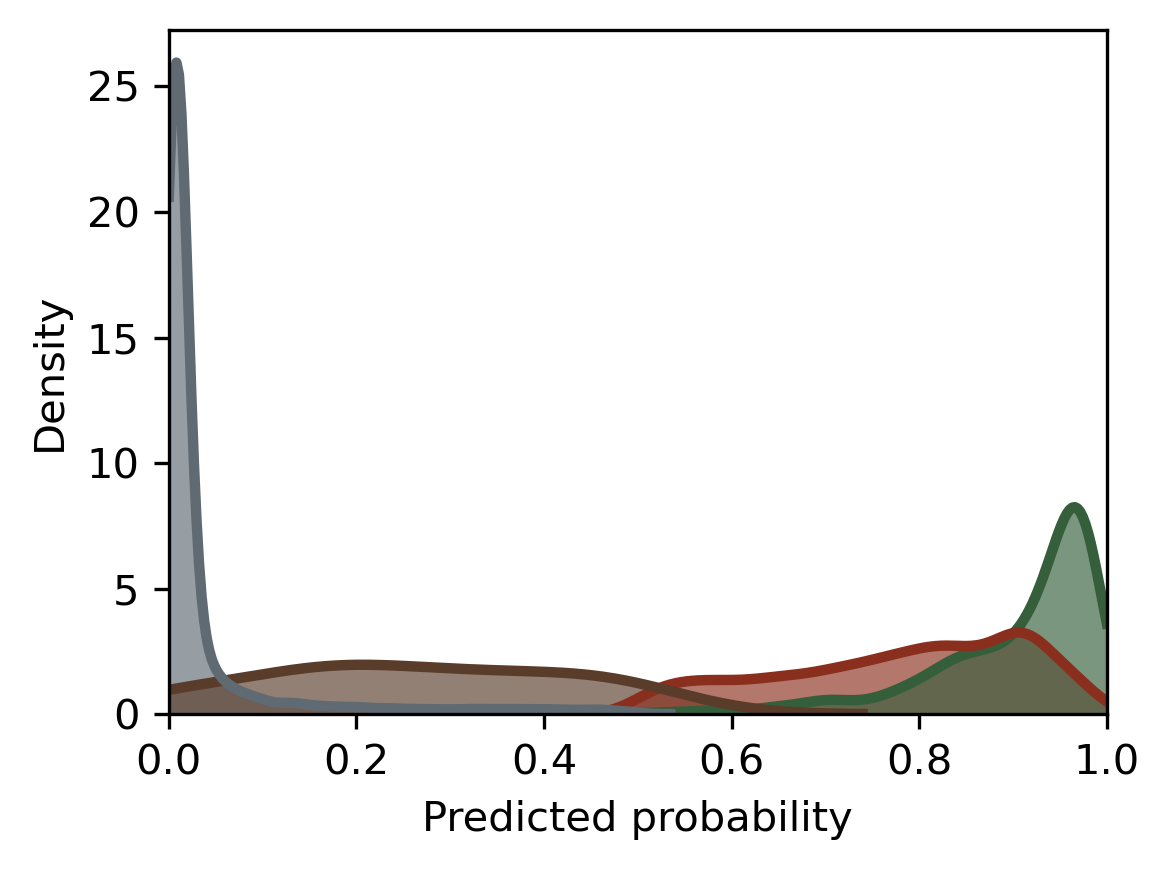

In [19]:
fig, ax = plt.subplots(figsize=(4, 3), dpi=300)

# Pass 1: faint fills as background hint — drawn in reverse so TP is on top
for cat in ["TN", "FN", "FP", "TP"]:
    grp = common_pairs.loc[common_pairs["cm_category"] == cat, "probability"]
    sns.kdeplot(grp, fill=True, alpha=0.65, color=cm_colors[cat],
                linewidth=0, bw_adjust=1, ax=ax, clip=(0, 1))

# Pass 2: full-opacity lines drawn on top — never blended, colour stays pure
for cat in ["TP", "FP", "FN", "TN"]:
    grp = common_pairs.loc[common_pairs["cm_category"] == cat, "probability"]
    sns.kdeplot(grp, fill=False, color=cm_colors[cat],
                label=f"{cat}  (n={len(grp):,})", linewidth=2.5,
                bw_adjust=1, ax=ax, clip=(0, 1))

plt.xlim(0, 1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Density")
#ax.set_title("Probability density by confusion matrix category")
#ax.legend()
plt.savefig("Figures/probability_density_by_confusion_matrix_category.svg", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()